In [247]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns


In [248]:
df = pd.read_csv("smartcart_customers.csv")

In [249]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [250]:
df.shape

(2240, 22)

In [251]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# Data Preprocessing 

## 1.) handle missing values 

In [252]:
df["Income"] = df["Income"].fillna(df["I
ncome"].median())

SyntaxError: unterminated string literal (detected at line 1) (4291557924.py, line 1)

In [253]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


## Feature Engineering 

In [254]:
# AGE 
df["Age"] = 2026-df["Year_Birth"]


In [255]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,88,88,3,8,10,4,7,0,1,69
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,1,6,2,1,1,2,5,0,0,72
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,21,42,1,8,2,10,4,0,0,61
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,3,5,2,2,0,4,6,0,0,42
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,27,15,5,5,3,6,5,0,0,45


In [256]:
## 2. customer joining dates 

df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"] , dayfirst=True)
reference_date = df["Dt_Customer"].max()

df["Customer_Tenure_Days"] = (reference_date - df["Dt_Customer"]).dt.days

In [257]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,42,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,45,161


In [258]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days'],
      dtype='object')

In [259]:
# spending, wine+fruit + meat + sweet + gold + fish 

df["Total_Spending"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

In [260]:
# Children , add teenagers and kids 

df["Total_Children"] = df["Kidhome"] + df["Teenhome"] 

In [261]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663,1617,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113,27,2
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312,776,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139,53,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161,422,1


In [262]:
df["Education"].value_counts()


#undergraduate , graduate , postgraduate

df["Education"] = df["Education"].replace({
    "Basic" : "Undergraduate" , "2n Cycle" : "Undergraduate" , 
    "Graduation" : "Graduate" , 
    "Master" : "Postgraduate" , "PhD" : "Postgraduate" 
})

In [263]:
# Marital Status 

df["Living_With"]  = df["Marital_Status"].replace({
    "Married" : "Partner" , "Together" : "Partner" , 
    "Single" : "Alone" , "Divorced" : "Alone" , 
    "Widow" : "Alone" , "Absurd" : "Alone" , "YOLO" : "Alone"
})

In [264]:
df["Living_With"].value_counts()

Living_With
Partner    1444
Alone       796
Name: count, dtype: int64

## Drop COLUMNS 

In [265]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,69,663,1617,0,Alone
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,72,113,27,2,Alone
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,61,312,776,0,Partner
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,42,139,53,1,Partner
4,5324,1981,Postgraduate,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,45,161,422,1,Partner


In [266]:
cols = ["ID" , "Year_Birth" , "Marital_Status" , "Kidhome" , "Teenhome" , "Dt_Customer" ]
spending_cols = ["MntWines" ,  "MntFruits" , "MntMeatProducts" , "MntFishProducts" , "MntSweetProducts" , "MntGoldProds" ]

cols_to_drop = cols + spending_cols
df_cleaned = df.drop(columns=cols_to_drop)


In [267]:
df_cleaned.shape

(2240, 15)

In [268]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


# Outliers

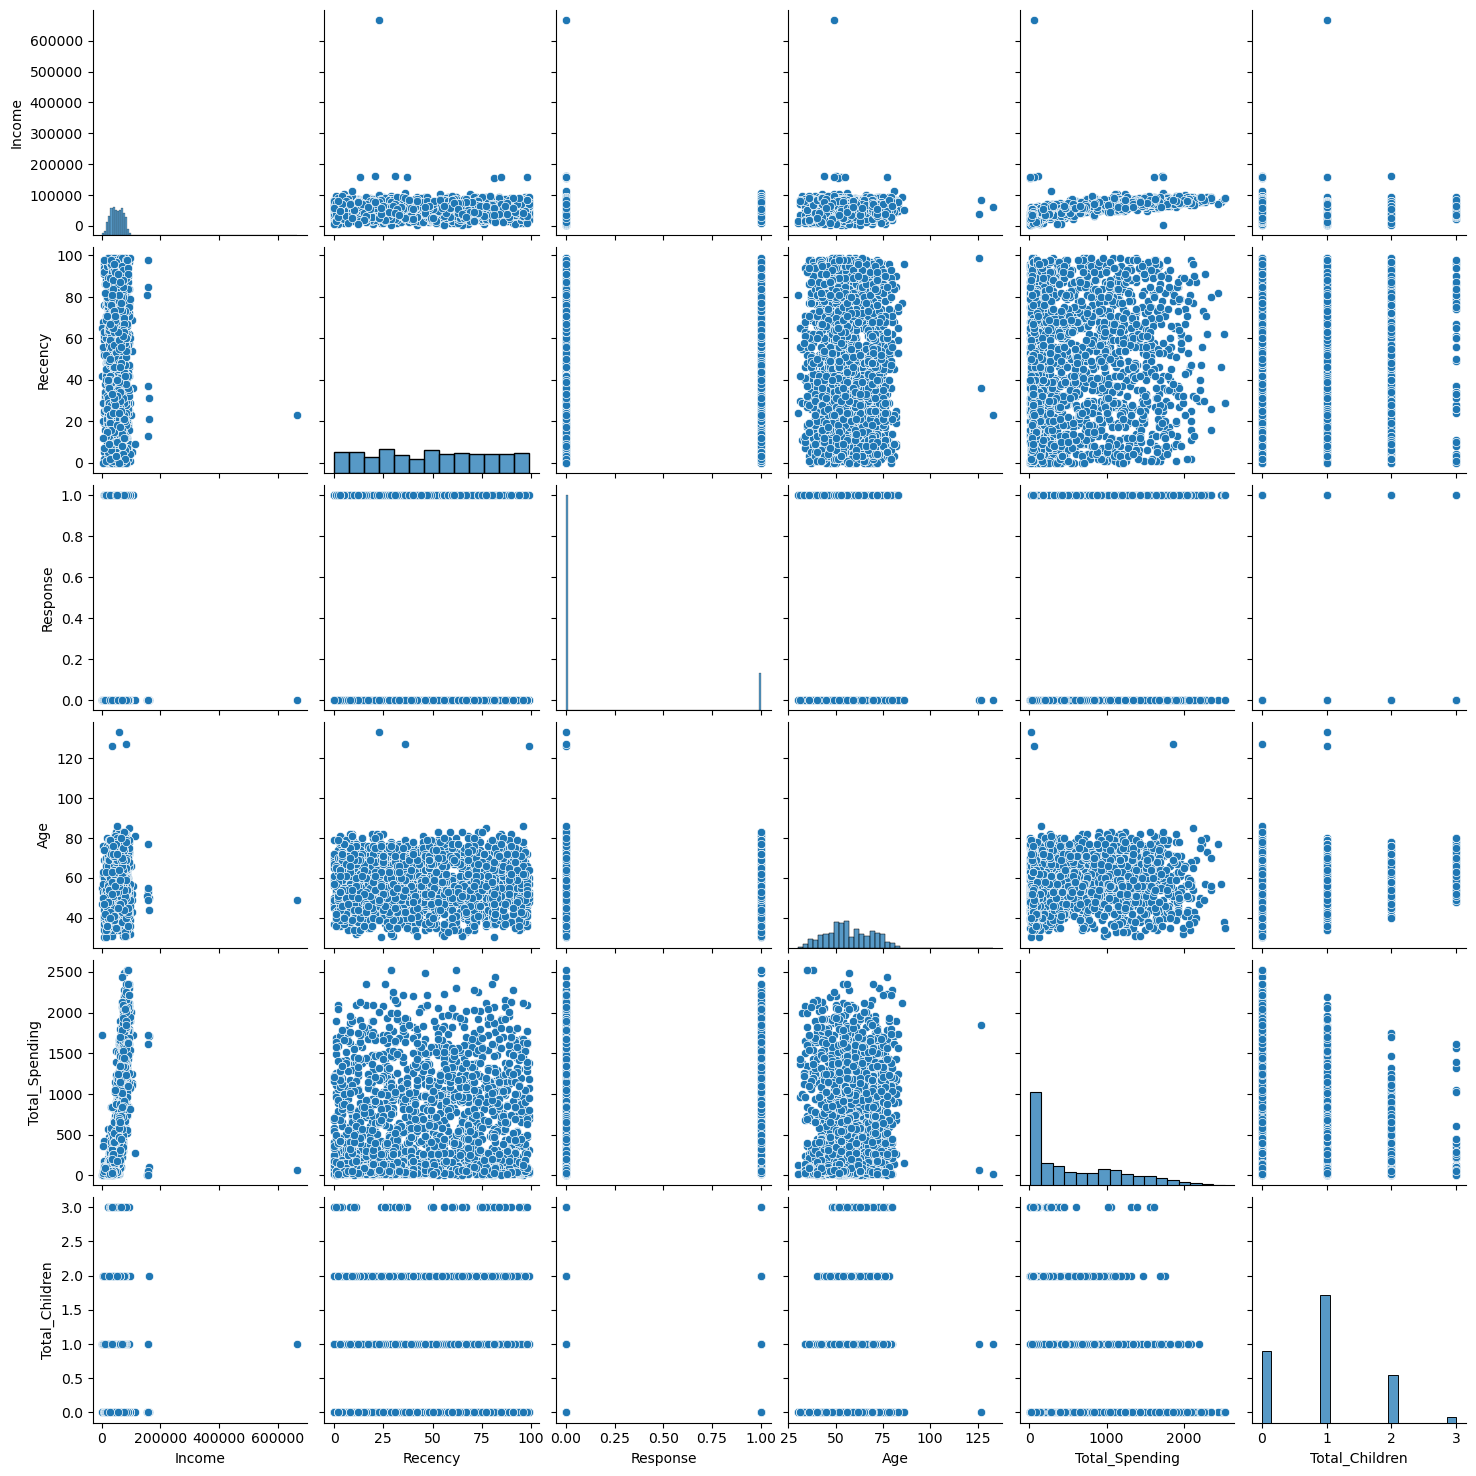

In [269]:
cols = ["Income" , "Recency" , "Response" , "Age" , "Total_Spending" , "Total_Children"]



# relative plots of some features - pair plots 
sns.pairplot(df_cleaned[cols])


In [270]:
# remove outliers 

print("data size with outliers : " , len(df_cleaned))
df_cleaned = df_cleaned[df_cleaned["Age"] < 90 ]
df_cleaned = df_cleaned[df_cleaned["Income"] < 600_000 ]

print("data size with outliers : " , len(df_cleaned))

data size with outliers :  2240
data size with outliers :  2212


# heatmap

In [271]:
corr = df_cleaned.corr(numeric_only = True)

<Axes: >

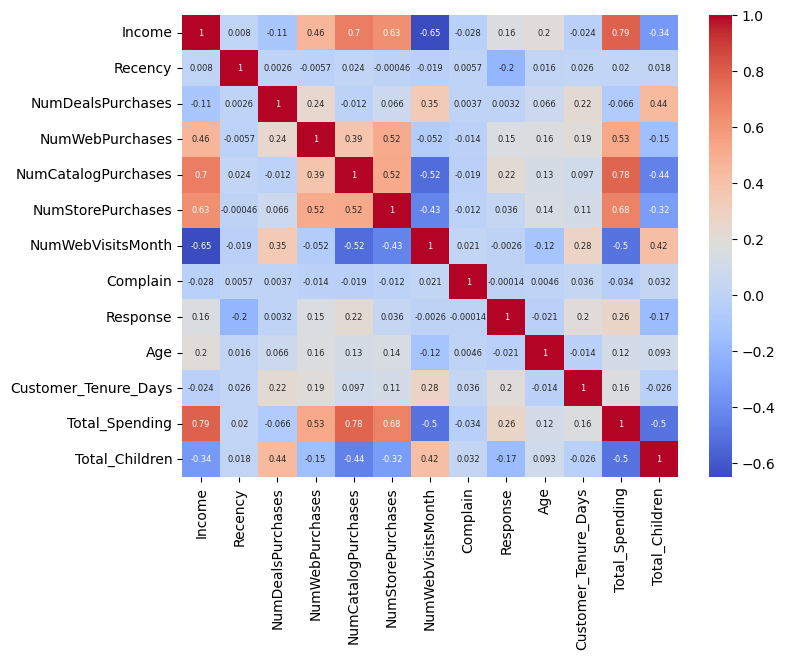

In [272]:
plt.figure(figsize = (8,6))
sns.heatmap(
    corr, 
    annot = True ,
    annot_kws = {"size" : 6} , 
    cmap = "coolwarm"
    
)

In [273]:
df_cleaned.shape

(2212, 15)

In [274]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


# encoding 

In [275]:
from sklearn.preprocessing import OneHotEncoder

In [276]:
ohe = OneHotEncoder()

cat_cols = ["Education" , "Living_With"]

enc_cols = ohe.fit_transform(df_cleaned[cat_cols])

In [277]:
enc_df = pd.DataFrame(enc_cols.toarray() , columns = ohe.get_feature_names_out(cat_cols) , index = df_cleaned.index)

In [278]:
enc_df.head()

,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0


In [279]:
df_encoded = pd.concat([df_cleaned.drop(columns = cat_cols) , enc_df] , axis = 1)

In [280]:
df_encoded.shape

(2212, 18)

In [281]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


# Scaling 

In [282]:
from sklearn.preprocessing import StandardScaler 


In [283]:
X = df_encoded

In [284]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [285]:
X_scaled

array([[ 0.28710487,  0.31035323,  0.35102992, ..., -0.35856858,
         1.34960312, -1.34960312],
       [-0.26088203, -0.38081349, -0.16870113, ..., -0.35856858,
         1.34960312, -1.34960312],
       [ 0.9131964 , -0.79551352, -0.68843217, ..., -0.35856858,
        -0.74095857,  0.74095857],
       ...,
       [ 0.23334696,  1.45077832, -0.68843217, ..., -0.35856858,
         1.34960312, -1.34960312],
       [ 0.80317156, -1.41756357, -0.16870113, ..., -0.35856858,
        -0.74095857,  0.74095857],
       [ 0.04229031, -0.31169682,  0.35102992, ..., -0.35856858,
        -0.74095857,  0.74095857]], shape=(2212, 18))

# Visualiize 


In [286]:
X_scaled.shape

(2212, 18)

In [287]:
# 2D VISUALIZATION 

from sklearn.decomposition import PCA 
pca = PCA(n_components = 3)
X_pca = pca.fit_transform(X_scaled)

In [288]:
pca.explained_variance_ratio_

array([0.23258254, 0.11390916, 0.10418299])

Text(0.5, 0.92, '3D-PROJECTION')

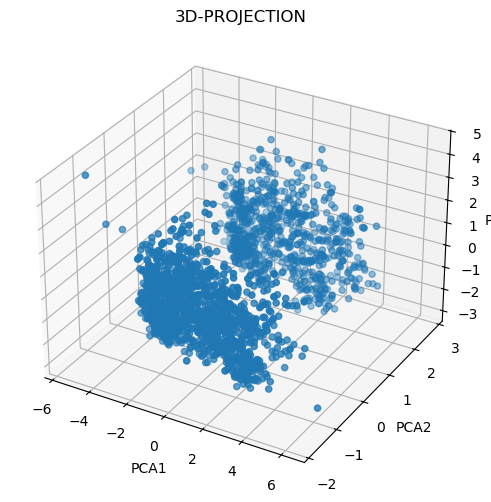

In [289]:
#PLOTTING 
fig = plt.figure(figsize = (8,6))

ax = fig.add_subplot(111, projection = "3d")



ax.scatter(X_pca[:,0] , X_pca[:,1] , X_pca[:,2])

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3D-PROJECTION")


In [290]:
pca.explained_variance_ratio_

array([0.23258254, 0.11390916, 0.10418299])

# analyze the k value 

## 1. ELBOW METHOD

In [291]:
from sklearn.cluster import KMeans

from kneed import KneeLocator

wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters = k , random_state = 42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

C:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, 

In [292]:
knee = KneeLocator(range(1,11) , wcss , curve = "convex" , direction = "decreasing")
optimal_k = knee.elbow

In [293]:
print("best k = " , optimal_k)

best k =  4


Text(0, 0.5, 'wcss')

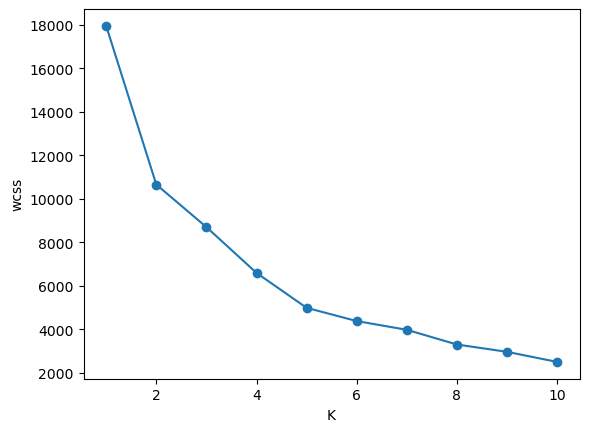

In [294]:
# plot 
plt.plot(range(1,11) , wcss , marker = 'o')

plt.xlabel("K")
plt.ylabel("wcss")


## Silhouette Score 


C:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, 

Text(0, 0.5, 'silhouette score')

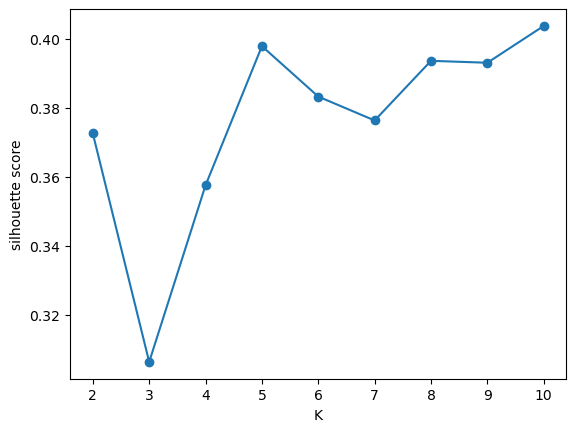

In [295]:
from sklearn.metrics import silhouette_score

scores = []

for k in range(2,11):
    kmeans = KMeans(n_clusters = k , random_state = 42 )
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca , labels)
    scores.append(score)


#plot

plt.plot(range(2,11) , scores , marker = 'o')

plt.xlabel("K")
plt.ylabel("silhouette score")




Text(0, 0.5, 'SilhouetteScore')

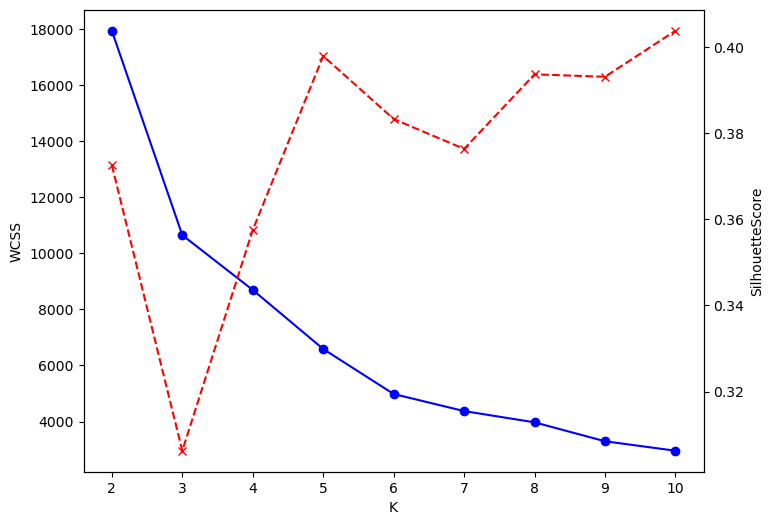

In [296]:
# combine plot 


k_range = range(2,11)

fig , ax1 = plt.subplots(figsize=(8,6))

ax1.plot(k_range , wcss[:len(k_range)] , marker = 'o' , color = "blue")
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")


ax2 = ax1.twinx()
ax2.plot(k_range , scores[:len(k_range)] , marker = 'x' , color = "red" , linestyle = "--")
ax2.set_ylabel("SilhouetteScore")


# clustering

In [297]:
# K_means 

kmeans = KMeans(n_clusters = 4 , random_state = 42)
labels_kmeans = kmeans.fit_predict(X_pca)

C:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


Text(0.5, 0.92, '3D-PROJECTION')

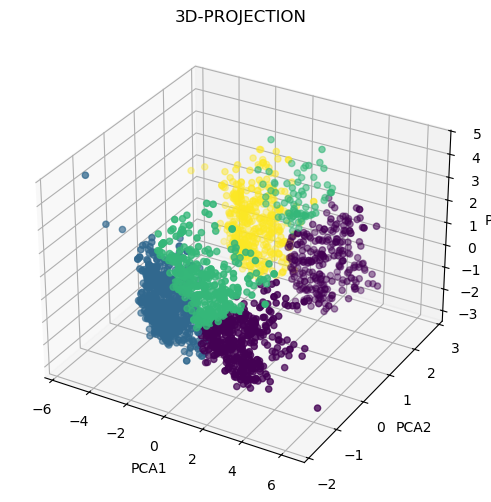

In [298]:
#PLOTTING 
fig = plt.figure(figsize = (8,6))

ax = fig.add_subplot(111, projection = "3d")



ax.scatter(X_pca[:,0] , X_pca[:,1] , X_pca[:,2] , c = labels_kmeans)

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3D-PROJECTION")


In [299]:
# agglomerative clustering 

from sklearn.cluster import AgglomerativeClustering


In [300]:
agg_clf = AgglomerativeClustering(n_clusters = 4 , linkage = "ward")

labels_agg = agg_clf.fit_predict(X_pca)

Text(0.5, 0.92, '3D-PROJECTION')

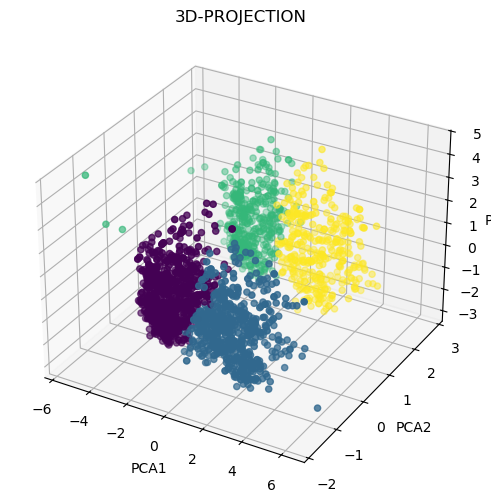

In [301]:
#PLOTTING 
fig = plt.figure(figsize = (8,6))
ax = fig.add_subplot(111, projection = "3d")
ax.scatter(X_pca[:,0] , X_pca[:,1] , X_pca[:,2] , c = labels_agg)

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3D-PROJECTION")



# Characterization of cluster 

In [337]:

X["clusters"] = labels_agg

In [338]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner,clusters
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='clusters', ylabel='count'>

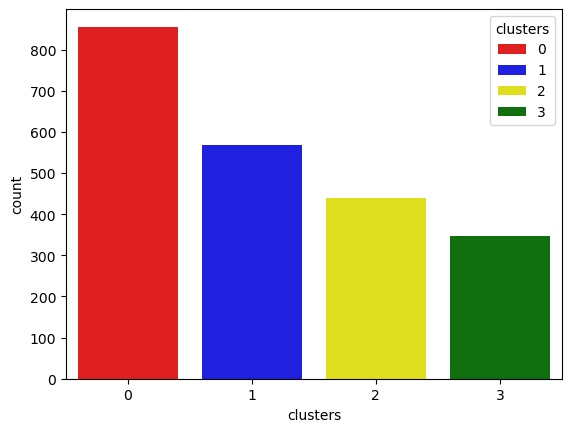

In [339]:
pal = ["red" , "blue" , "yellow" , "green"]
sns.countplot(x = X["clusters"] , palette = pal , hue = X["clusters"])

<Axes: xlabel='Total_Spending', ylabel='Income'>

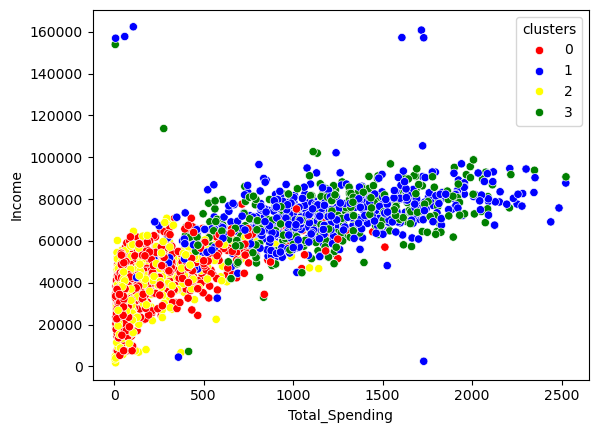

In [340]:
# INCOME AND SPENDING PATTERNS 

sns.scatterplot(x=X["Total_Spending"] , y = X["Income"] , hue = X["clusters"] , palette = pal)

In [341]:
#Cluster summary 

cluster_summary = X.groupby("clusters").mean()
print(cluster_summary)



                Income    Recency  NumDealsPurchases  NumWebPurchases  \
clusters                                                                
0         38814.688084  49.113318           2.643692         3.063084   
1         71785.449912  48.810193           1.919156         5.662566   
2         36861.452273  48.034091           2.600000         2.736364   
3         71016.011527  50.380403           1.853026         5.749280   

          NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
clusters                                                                        
0                    0.941589           4.070093           6.477804  0.009346   
1                    5.230228           8.469244           3.520211  0.008787   
2                    0.854545           3.643182           6.659091  0.011364   
3                    5.051873           8.466859           3.726225  0.005764   

          Response        Age  Customer_Tenure_Days  Total_Spending  \
clu